In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFE

In [3]:
df_1 = pd.read_csv('../data/raw/student-mat.csv')
df_2 = pd.read_csv('../data/raw/student-por.csv')

In [5]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [7]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [8]:
df = pd.concat([df_1, df_2], ignore_index=True)

In [9]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [33]:
df_processed = df.drop(columns=['G1', 'G2'], axis=1)

In [34]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [35]:
list_object_types = list(df_processed.dtypes[df_processed.dtypes=='object'].index)

In [36]:
df_processed = pd.get_dummies(df_processed, 
               columns=list_object_types,
               drop_first=True)

In [37]:
df_processed.head(5)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [38]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   age                1044 non-null   int64
 1   Medu               1044 non-null   int64
 2   Fedu               1044 non-null   int64
 3   traveltime         1044 non-null   int64
 4   studytime          1044 non-null   int64
 5   failures           1044 non-null   int64
 6   famrel             1044 non-null   int64
 7   freetime           1044 non-null   int64
 8   goout              1044 non-null   int64
 9   Dalc               1044 non-null   int64
 10  Walc               1044 non-null   int64
 11  health             1044 non-null   int64
 12  absences           1044 non-null   int64
 13  G3                 1044 non-null   int64
 14  school_MS          1044 non-null   bool 
 15  sex_M              1044 non-null   bool 
 16  address_U          1044 non-null   bool 
 17  famsize_LE3   

In [92]:
y = df_processed['G3']
X = df_processed.drop('G3', axis=1)

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

In [94]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [95]:
predictions = model.predict(X_test)
n = X.shape[0]
k = X.shape[1]
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
r2_adj = 1-(1-r2)*(n-1)/(n-k)
print(f'n = {n}')
print(f'k = {k}')
print(f'mae = {mae:.2f}')
print(f'mse = {mse:.2f}')
print(f'rmse = {rmse:.2f}')
print(f'R^2 = {r2:.3f}')
print(f'R^2_adj = {r2_adj:.3f}')

n = 1044
k = 39
mae = 2.43
mse = 11.74
rmse = 3.43
R^2 = 0.136
R^2_adj = 0.103


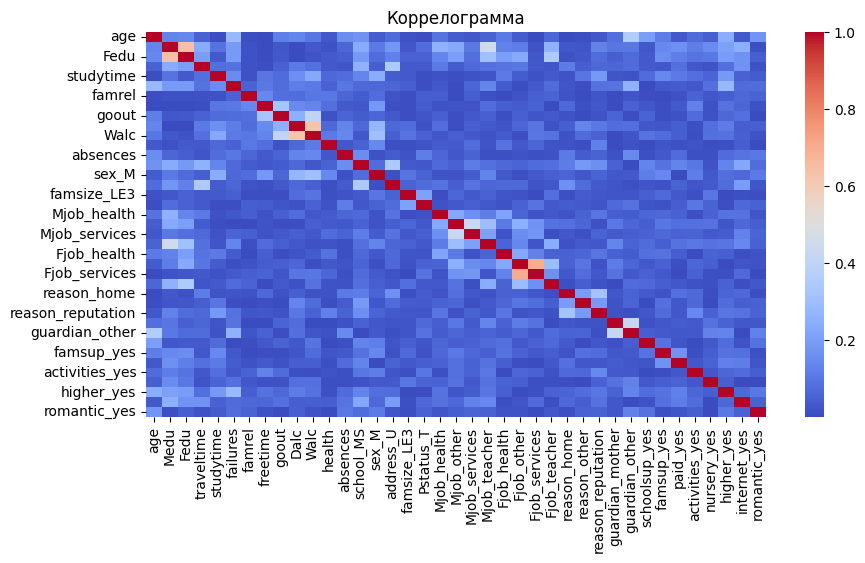

In [96]:
corr_data = abs(X.corr())
plt.figure(figsize=(10,5)) # Размер рисунка
plt.title('Коррелограмма') # Заголовок
sns.heatmap(corr_data, cmap='coolwarm')
plt.show() # Показать график

In [97]:
top_k = 5
top_k_features = df_processed.corr()['G3'].abs().sort_values(ascending=False).drop(['G3', 'Fedu', 'Walc', 'Fjob_other'], axis=0)[:top_k].index.to_list()

In [98]:
top_k_features

['failures', 'higher_yes', 'Medu', 'studytime', 'Dalc']

In [99]:
X_top_k = X[top_k_features]

In [100]:
X_top_k_train, X_top_k_test, y_top_k_train, y_top_k_test = train_test_split(X_top_k, y, test_size=0.2, random_state=5)

In [101]:
model_top_k = LinearRegression()
model_top_k.fit(X_top_k_train, y_top_k_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
predictions_top_k = model_top_k.predict(X_top_k_test)
n = X_top_k.shape[0]
k = X_top_k.shape[1]
mae = mean_absolute_error(y_top_k_test, predictions_top_k)
mse = mean_squared_error(y_top_k_test, predictions_top_k)
rmse = np.sqrt(mse)
r2 = r2_score(y_top_k_test, predictions_top_k)
r2_adj = 1-(1-r2)*(n-1)/(n-k)
print(f'n = {n}')
print(f'k = {k}')
print(f'mae = {mae:.2f}')
print(f'mse = {mse:.2f}')
print(f'rmse = {rmse:.2f}')
print(f'R^2 = {r2:.3f}')
print(f'R^2_adj = {r2_adj:.3f}')

n = 1044
k = 5
mae = 2.37
mse = 11.29
rmse = 3.36
R^2 = 0.169
R^2_adj = 0.166


In [107]:
model_rfe = LinearRegression()
rfe = RFE(model_rfe, n_features_to_select=5)
rfe.fit(X_train, y_train)

,estimator,LinearRegression()
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [112]:
rfe_features = X_train.columns[rfe.support_].to_list()

In [113]:
rfe_features

['failures', 'school_MS', 'Fjob_teacher', 'schoolsup_yes', 'higher_yes']

In [114]:
top_k_features

['failures', 'higher_yes', 'Medu', 'studytime', 'Dalc']

In [115]:
X_rfe = X[rfe_features]
X_rfe_train, X_rfe_test, y_rfe_train, y_rfe_test = train_test_split(X_rfe, y, test_size=0.2, random_state=5)
model_rfe = LinearRegression()
model_rfe.fit(X_rfe_train, y_rfe_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [116]:
predictions_rfe = model_rfe.predict(X_rfe_test)
n = X_rfe.shape[0]
k = X_rfe.shape[1]
mae = mean_absolute_error(y_rfe_test, predictions_rfe)
mse = mean_squared_error(y_rfe_test, predictions_rfe)
rmse = np.sqrt(mse)
r2 = r2_score(y_rfe_test, predictions_rfe)
r2_adj = 1-(1-r2)*(n-1)/(n-k)
print(f'n = {n}')
print(f'k = {k}')
print(f'mae = {mae:.2f}')
print(f'mse = {mse:.2f}')
print(f'rmse = {rmse:.2f}')
print(f'R^2 = {r2:.3f}')
print(f'R^2_adj = {r2_adj:.3f}')

n = 1044
k = 5
mae = 2.38
mse = 11.60
rmse = 3.41
R^2 = 0.147
R^2_adj = 0.144
